# EDA on income data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns
from PIL import Image as PILImage
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
import stat

# import PCA
from sklearn.manifold import TSNE
# import umap


In [2]:
df = pd.read_csv("adult.csv")


## Data cleaning and descriptive analysis

First we will try finding:
- number of rows in the data.
- the number of columns in the data.
- number of null rows in the data
- data type of the columns.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


From the data above we can see that there are total of 32561 rows of data.

there are no null values in the data.

there are 6 columns with integer data types. and 9 columns with object data-type. we have yet to find if there are any categorical columns in the data.

Next we will print the first 5 rows of data to see what kind data we have

In [4]:
df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


From the data, we can see that in object datatype columns, instead of having None, they have ? as the place holder for null values.
We can find the number of null values in the data by counting the '?' in each column but first we will check for any duplicate values in the dataset

In [5]:
print(f"The number of duplicated rows in the dataset are {df.duplicated().sum()}")
df[df.duplicated(keep=False)]


The number of duplicated rows in the dataset are 24


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
6227,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
7615,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
7978,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
8356,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
8453,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
8500,38,Private,207202,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,48,United-States,>50K
8645,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
9067,27,Private,255582,HS-grad,9,Never-married,Machine-op-inspct,Not-in-family,White,Female,0,0,40,United-States,<=50K
9269,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
9305,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K


We will first drop these duplicated rows, check if the code has been executed properly and then find the number of actual null values in the dataset

In [6]:
# 1. Remove duplicates
df.drop_duplicates(inplace=True)

# 2. Verify duplicates removed
display(
    f"Number of duplicate rows in the dataset after removal is: {df.duplicated().sum()}"
)

# 3. Find '?' counts per column
display("Finding number of '?' in each column")
for col in df.columns:
    question_marks = (df[col] == "?").sum()
    display(f"{col}: {question_marks}")


'Number of duplicate rows in the dataset after removal is: 0'

"Finding number of '?' in each column"

'age: 0'

'workclass: 1836'

'fnlwgt: 0'

...

'capital.gain: 0'

'capital.loss: 0'

'hours.per.week: 0'

'native.country: 582'

'income: 0'

this means that there are atleast 582 rows of data with ? in the columns and at most 4261 rows of data with ? in them making it 13% of the data.

next we will apply descriptive statistices on the data.

In [7]:
df.describe()


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


From this data we get the following:
- max values for the capital.gain, capital.loss and hours per week are likely outliers. considering the huge difference between the 75% quartile and the maximum quartile.

The rest of the data seems normal

Before moving on, I will first remove the the rows containing '?' within them

In [8]:
def clean_and_report(df):
    import numpy as np

    # Replace '?' with NaN and drop rows containing them
    df.replace("?", np.nan, inplace=True)
    df.dropna(inplace=True)

    display("✅ Cleaned dataset. Now checking for remaining '?' in each column:")

    # Check remaining '?' per column (should be 0 if cleaned)
    for col in df.columns:
        question_marks = (df[col] == "?").sum()
        display(f"{col}: {question_marks}")


clean_and_report(df)


"✅ Cleaned dataset. Now checking for remaining '?' in each column:"

'age: 0'

'workclass: 0'

'fnlwgt: 0'

'education: 0'

...

'capital.gain: 0'

'capital.loss: 0'

'hours.per.week: 0'

'native.country: 0'

'income: 0'

Since the data is now considered clean, we will now move onto Visualization of data and we will also try to answer some of the questions that might arise in the stock holders mind. these questions might be:
- which occupation has the highest pay.
- which sex gets paid the most.
- what is the age of the people and whether there is a co-relation between jobs or pay.
- does race effect income.
- does private work-class gets paid more than public or vice-versa

## Performing data visualization

Text(0.5, 1.0, 'Correlation Heatmap')

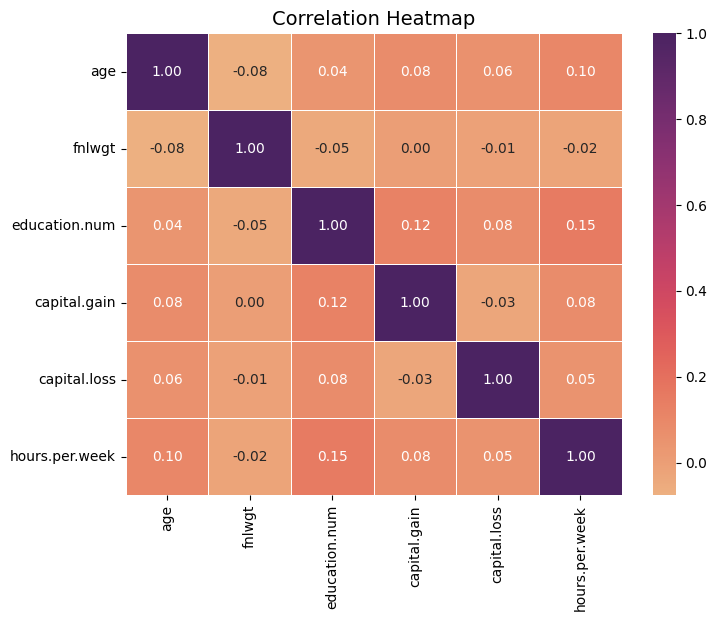

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="flare", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14)


here we can see that columns have no relation to each other.

Next, we will draw graphs to find the distribution of the data.

**Distribution of gender in the data**

Text(0.5, 1.0, 'Distribution of gender')

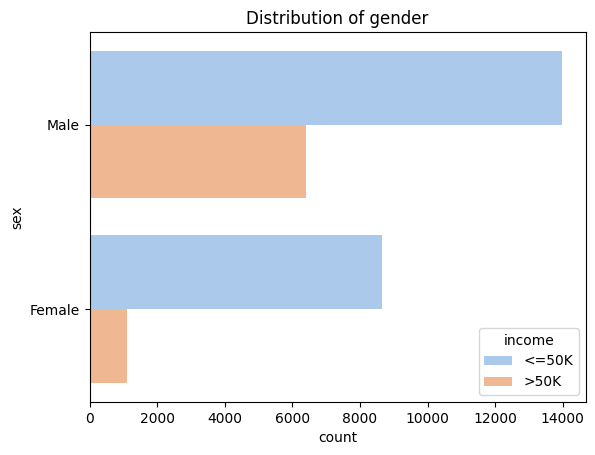

In [10]:
sns.countplot(
    data=df,
    y="sex",
    order=df["sex"].value_counts().index,
    palette="pastel",
    hue="income",
)
plt.title("Distribution of gender")


here, we can see that the dataset contains more data from males than females.

**Distribution of data in regards to Location.**

In [11]:
# Calculate value counts and percentages
counts = df["native.country"].value_counts()
percentages = counts / counts.sum() * 100

# Combine into a single DataFrame
country_dist = pd.DataFrame({"Count": counts, "Percentage": percentages.round(2)})

# Optional: sort descending by count
country_dist = country_dist.sort_values(by="Count", ascending=False)

# Display the table
display(country_dist)


,Count,Percentage
native.country,,
United-States,27487,91.20
Mexico,606,2.01
Philippines,188,0.62
Germany,128,0.42
Puerto-Rico,109,0.36
Canada,107,0.36
El-Salvador,100,0.33
India,100,0.33
Cuba,92,0.31


Almost all of the data is from United States, which means that the data is not a good representation of income through out the world. but it will work to estimate income disparity in US

**Distribution of occupation**

In [12]:
df["occupation"].value_counts()


occupation
Prof-specialty       4034
Craft-repair         4025
Exec-managerial      3991
Adm-clerical         3719
Sales                3584
Other-service        3209
Machine-op-inspct    1964
Transport-moving     1572
Handlers-cleaners    1349
Farming-fishing       987
Tech-support          911
Protective-serv       644
Priv-house-serv       141
Armed-Forces            9
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of occupation')

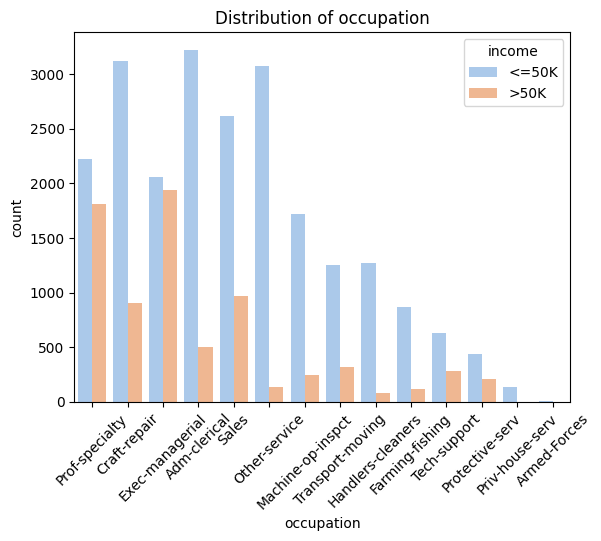

In [13]:
sns.countplot(
    data=df,
    x="occupation",
    order=df["occupation"].value_counts().index,
    hue="income",
    palette="pastel",
)
plt.xticks(rotation=45)
plt.title("Distribution of occupation")


**KDE Plots**

In [14]:
# ...existing code...
def summarize_numeric(df, numeric_cols):
    # build empty stats frame and compute skewness/kurtosis
    stats_df = pd.DataFrame(index=numeric_cols, columns=["Skewness", "Kurtosis"])
    for col in numeric_cols:
        stats_df.loc[col, "Skewness"] = float(df[col].skew(skipna=True))
        stats_df.loc[col, "Kurtosis"] = float(df[col].kurtosis(skipna=True))
    return stats_df


def plot_kde_grid(df, numeric_cols, ncols=2, figsize=(15, 5)):
    # flexible grid: ncols columns, enough rows to fit all plots
    import math

    n = len(numeric_cols)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=(figsize[0], figsize[1] * nrows)
    )
    axes = np.array(axes).reshape(-1)  # flatten axes for easy indexing
    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        sns.kdeplot(data=df, x=col, ax=ax, fill=True)
        ax.set_title(col)
    # hide any unused axes
    for j in range(n, axes.size):
        axes[j].set_visible(False)
    plt.tight_layout()
    return fig


# ...existing code...


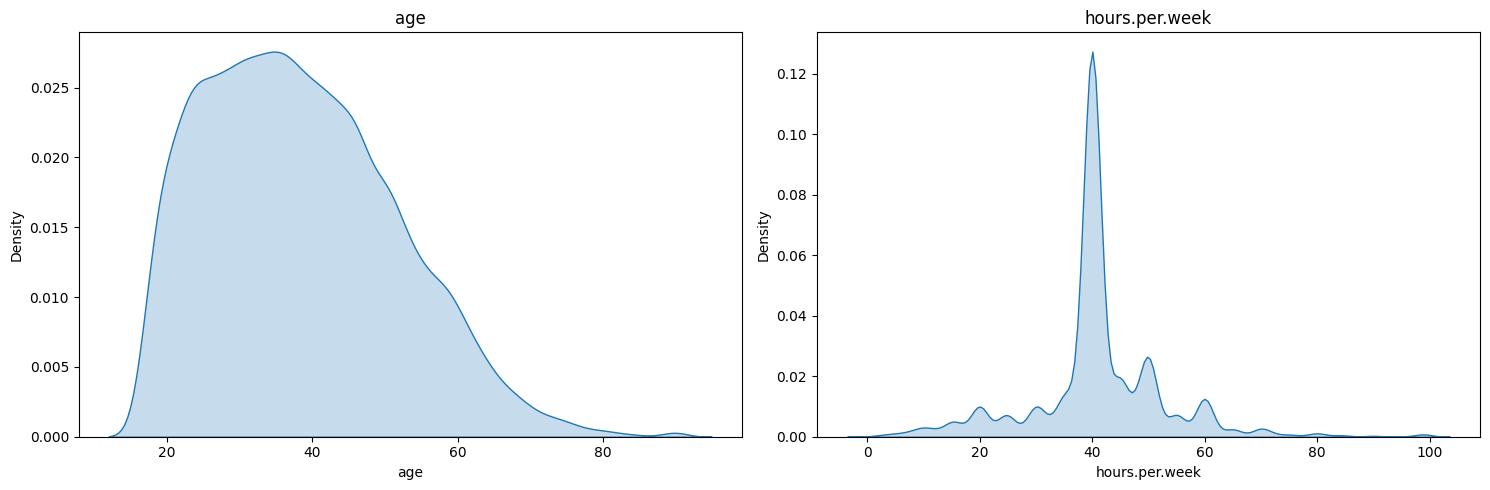

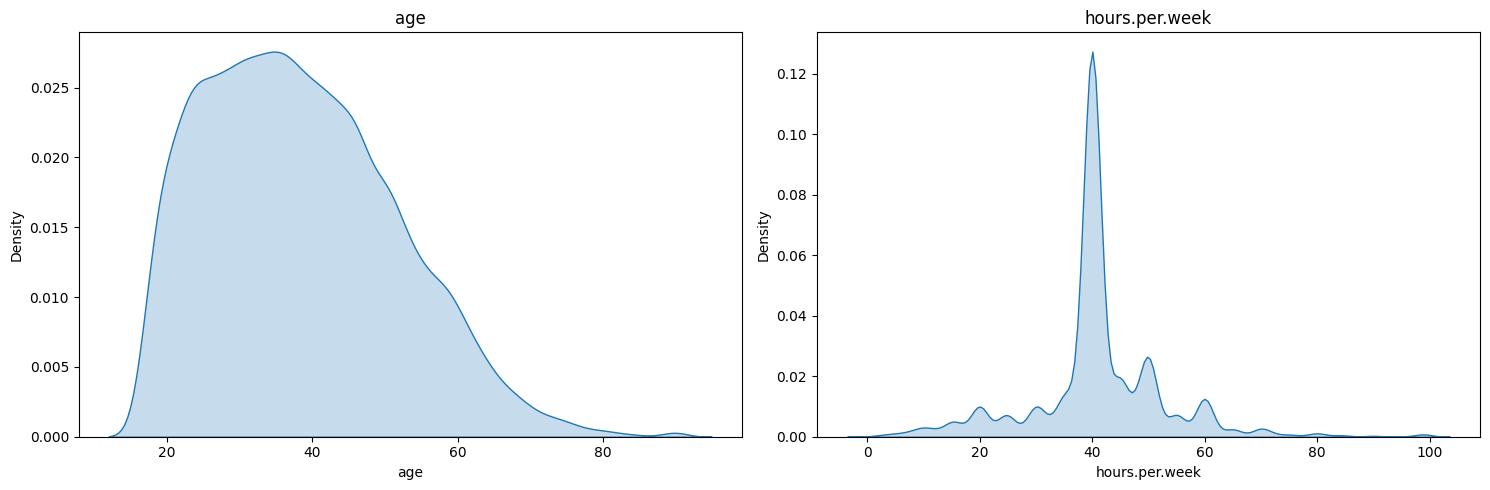

In [15]:
stat_df = summarize_numeric(df, numeric_cols=["age", "hours.per.week"])
plot_kde_grid(df, ["age", "hours.per.week"])


##### Finding and removing outliers:

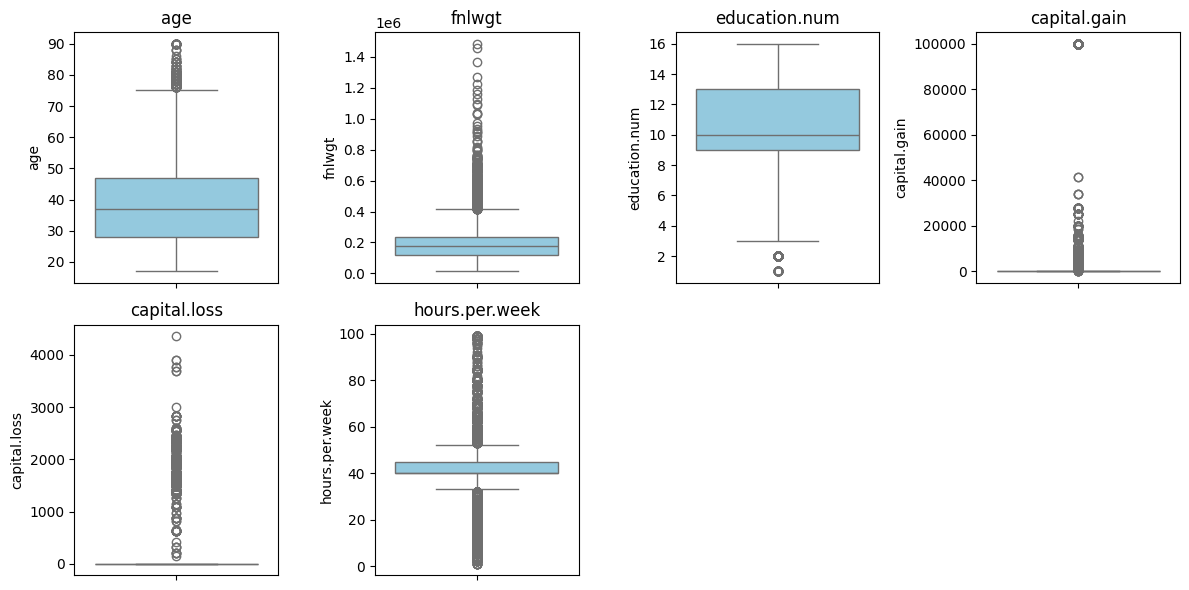

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()


In [17]:
def remove_outliers(df, numeric_cols, factor=1.5):
    """
    remove outliers in numeric columns using the IQR method .

    Parameters:
        df (pd.DataFrame): Input dataframe
        numeric_cols (list): List of numeric columns to process
        factor (float): Multiplier for IQR (default 1.5)

    Returns:
        pd.DataFrame: A copy of df with capped values
    """
    df_outliers = df.copy()
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (factor * IQR)
        upper_bound = Q3 + (factor * IQR)

        df_outliers = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)].any()
    return df_outliers


In [18]:
def winsorize_outliers(df, numeric_cols, factor=1.5):
    """
    Caps/floors outliers in numeric columns using the IQR method (winsorization).

    Parameters:
        df (pd.DataFrame): Input dataframe
        numeric_cols (list): List of numeric columns to process
        factor (float): Multiplier for IQR (default 1.5)

    Returns:
        pd.DataFrame: A copy of df with capped values
    """
    df_winsorized = df.copy()
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        df_winsorized[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df_winsorized


winsorized_df = winsorize_outliers(df, numeric_cols)


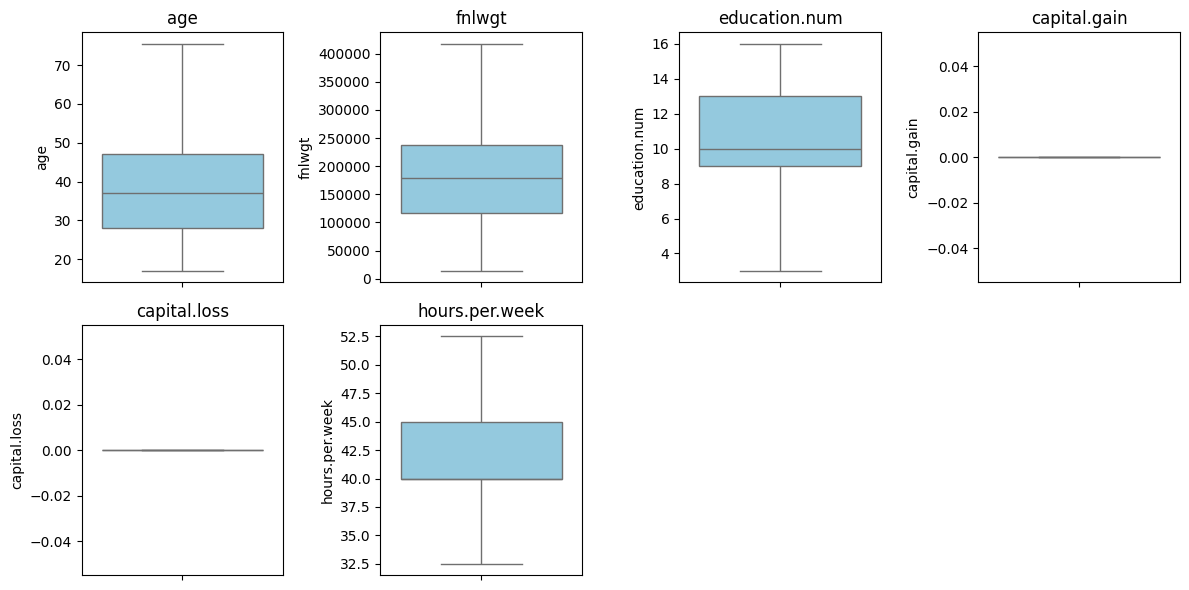

In [19]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=winsorized_df[col], color="skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()


In [20]:
df.drop(columns=["capital.loss", "capital.gain", "fnlwgt"], inplace=True)


In [21]:
# ...existing code...
categorical_col = df.select_dtypes(include="object")
scaler = StandardScaler()

# Encode categorical columns (new LabelEncoder per column)
for col in categorical_col.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Scale numeric columns in one call
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
# ...existing code...


In [22]:
def run_tsne(df, n_components=2, perplexity=30, learning_rate=200):
    ts = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        learning_rate=learning_rate,
        init="pca",
    )
    xt = ts.fit_transform(df)
    return xt


In [ ]:
xt = run_tsne(df)


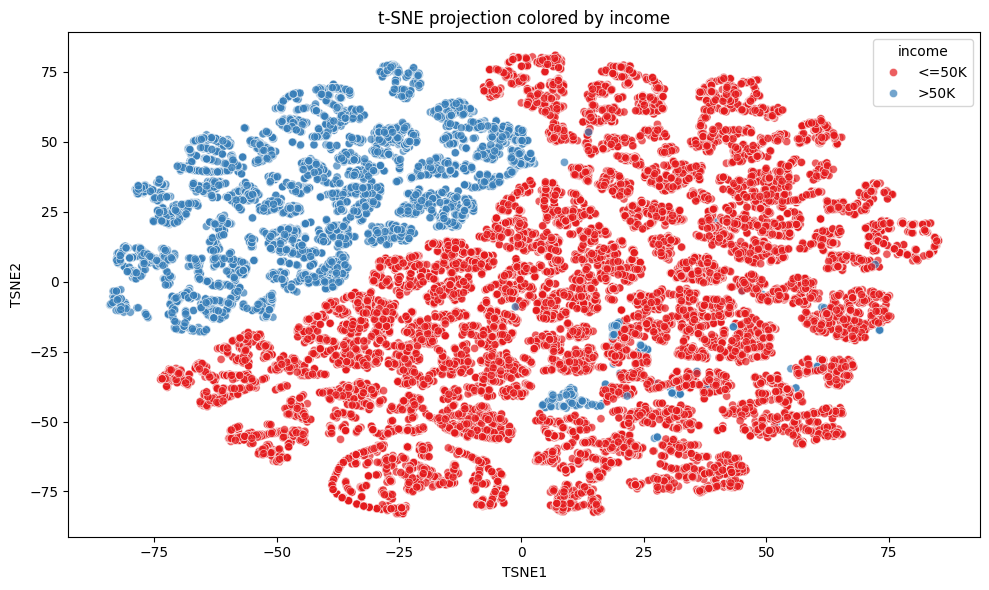

In [ ]:
# run TSNE and plot 2D embedding colored by original income labels

# build a dataframe for plotting
emb = pd.DataFrame(xt, columns=["TSNE1", "TSNE2"], index=df.index)
# use the original income labels from categorical_col (object dtype)
emb["income_label"] = categorical_col["income"]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=emb,
    x="TSNE1",
    y="TSNE2",
    hue="income_label",
    palette="Set1",
    alpha=0.7,
    s=35,
)
plt.title("t-SNE projection colored by income")
plt.legend(title="income", loc="best")
plt.tight_layout()
plt.show()


Embedding columns:
 Index(['TSNE1', 'TSNE2', 'income_label'], dtype='object') 



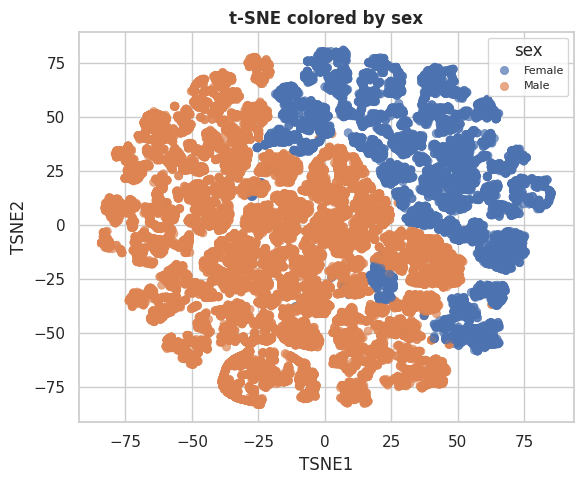

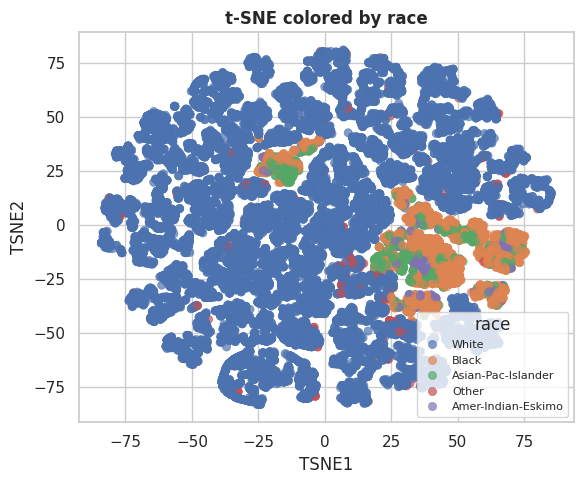

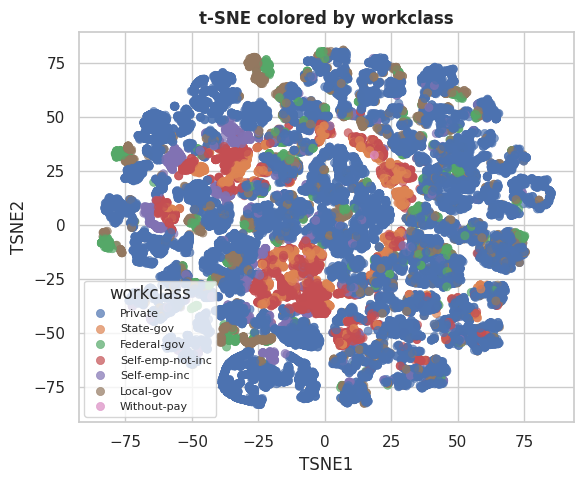

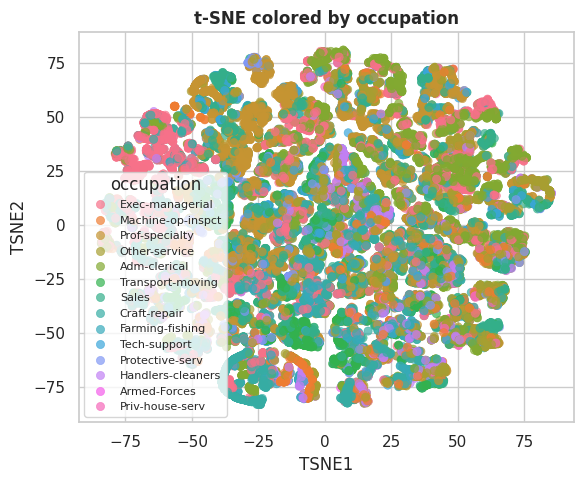

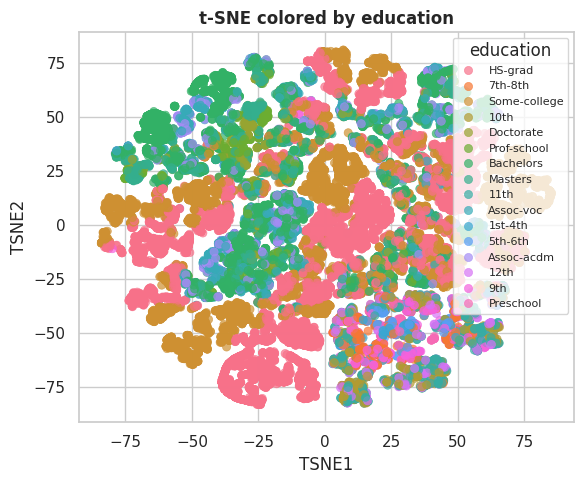

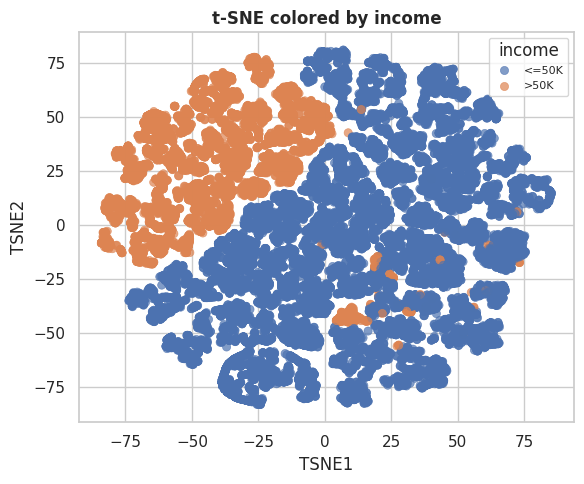

In [ ]:
# Inspect columns to confirm alignment between emb and df
print("Embedding columns:\n", emb.columns, "\n")

# Restore actual categorical labels from the original DataFrame
categorical_cols = ["sex", "race", "workclass", "occupation", "education", "income"]
for col in categorical_cols:
    if col in df.columns:
        emb[col] = categorical_col[col].astype(str)
    else:
        print(f"Warning: Column '{col}' not found in df")

# Generate t-SNE scatterplots with actual class labels
sns.set(style="whitegrid", rc={"figure.figsize": (6, 5)})

for col in categorical_cols:
    plt.figure()
    sns.scatterplot(
        data=emb, x="TSNE1", y="TSNE2", hue=col, s=35, alpha=0.7, edgecolor=None
    )
    plt.title(f"t-SNE colored by {col}", fontsize=12, weight="bold")
    plt.legend(title=col, loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


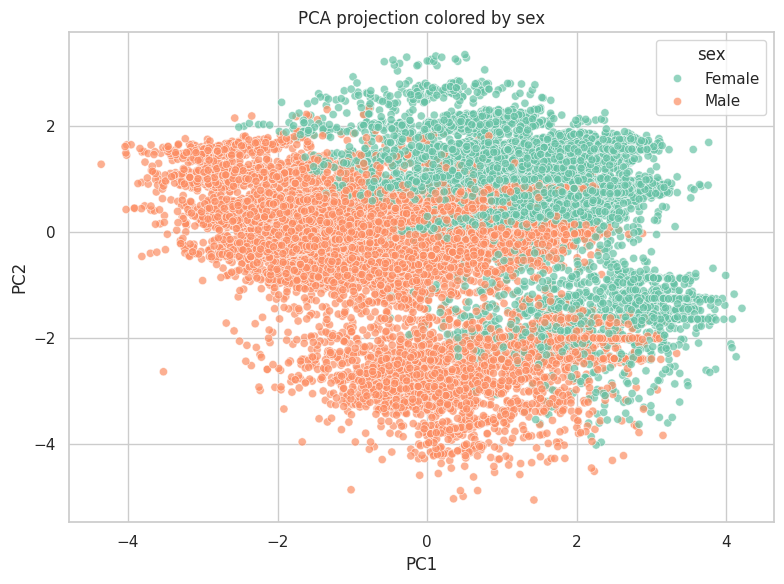

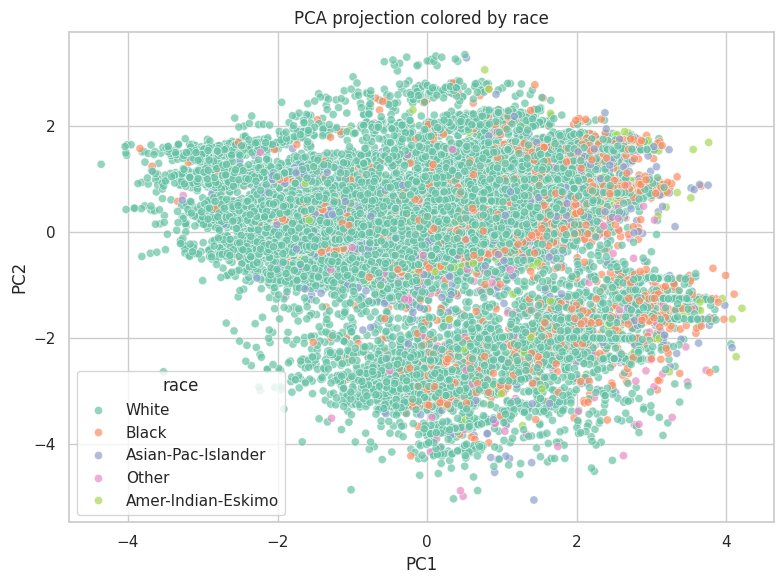

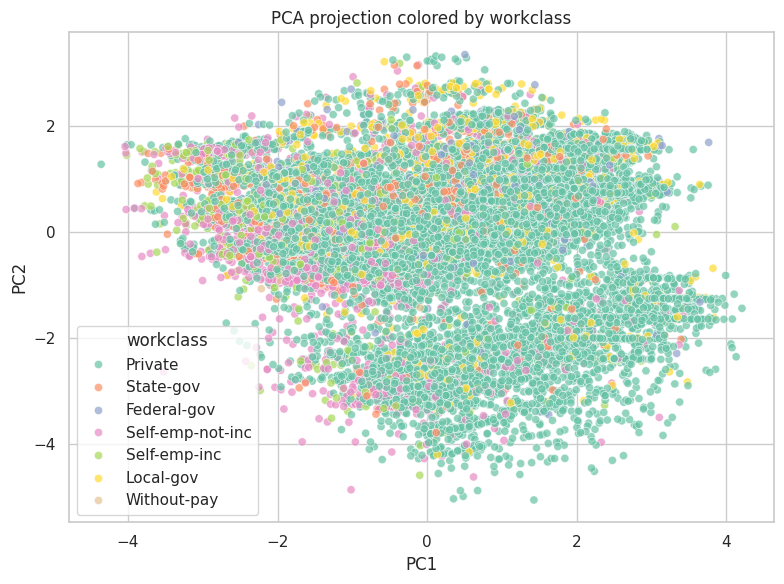

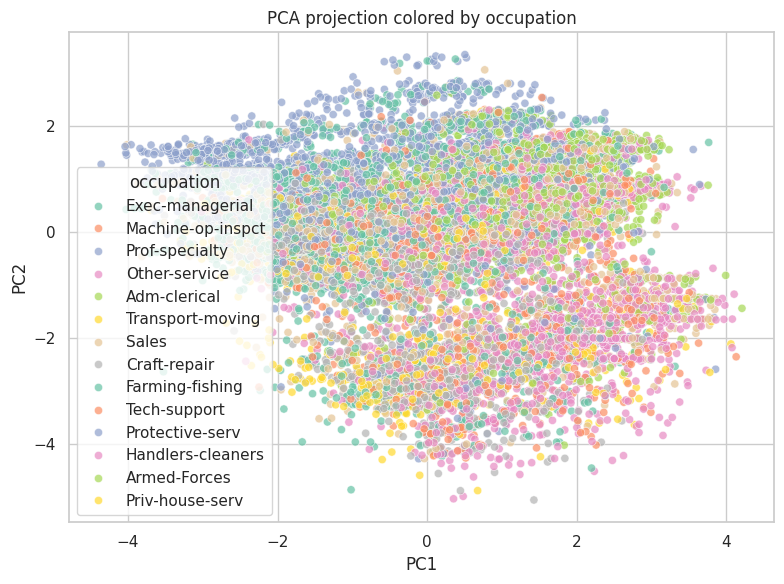

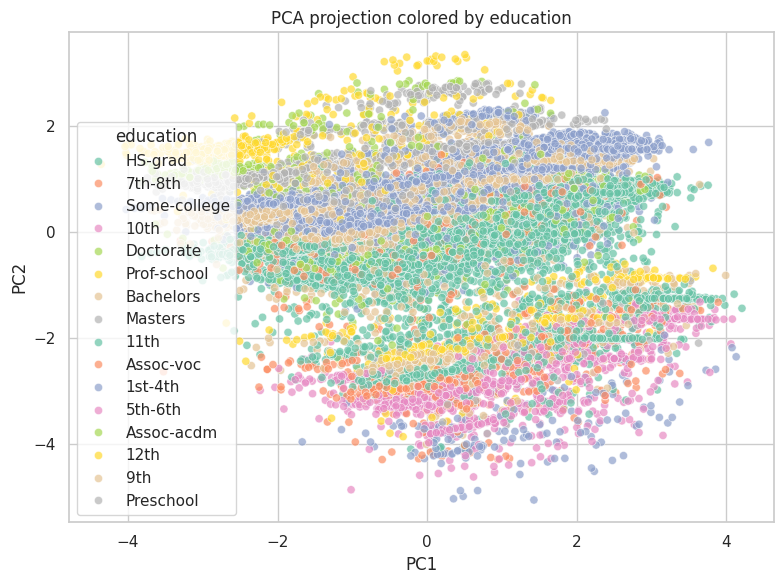

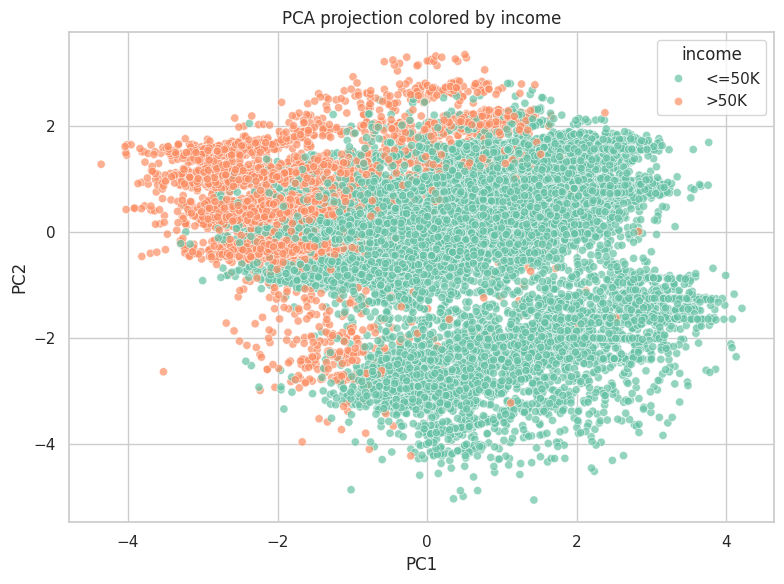

Explained variance by components:
  PC1: 19.17%
  PC2: 11.85%
Total explained variance (2 PCs): 31.02%


In [ ]:
from sklearn.decomposition import PCA


# --- STEP 2: Run PCA ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df[numeric_cols])

# --- STEP 3: Create a dataframe for plotting ---
emb = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=df.index)

# add relevant categorical labels for coloring
for col in ["sex", "race", "workclass", "occupation", "education", "income"]:
    emb[col] = categorical_col[col].astype(str)

# --- STEP 4: Visualize PCA embeddings for each category ---
for col in ["sex", "race", "workclass", "occupation", "education", "income"]:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=emb, x="PC1", y="PC2", hue=col, s=35, alpha=0.7, palette="Set2"
    )
    plt.title(f"PCA projection colored by {col}")
    plt.tight_layout()
    plt.show()

# --- STEP 5: Inspect explained variance ---
print("Explained variance by components:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i + 1}: {ratio:.2%}")
print(f"Total explained variance (2 PCs): {pca.explained_variance_ratio_.sum():.2%}")


In [ ]:
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=numeric_cols)
print(loadings.sort_values(by="PC2", ascending=False).head(10))


                     PC1       PC2
education.num  -0.255987  0.598870
education      -0.119018  0.580959
relationship    0.476270  0.281374
native.country -0.058695  0.237564
income         -0.411964  0.189985
marital.status  0.307170  0.029131
occupation     -0.069193  0.007364
hours.per.week -0.355255  0.006829
race           -0.145950  0.000239
workclass      -0.110076 -0.034697


In [ ]:
# UMAP for visualization
from umap import UMAP
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def run_umap(
    df,
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
):
    """
    Runs UMAP on a standardized numeric dataframe.

    Parameters:
        df (pd.DataFrame): numeric data
        n_components (int): output dimensions (2 or 3 typical)
        n_neighbors (int): controls local vs global structure
        min_dist (float): controls tightness of clusters
        metric (str): distance metric ('euclidean', 'cosine', etc.)
        random_state (int): reproducibility seed

    Returns:
        np.ndarray: low-dimensional embedding
    """
    reducer = UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
    )
    embedding = reducer.fit_transform(df)
    return embedding


# Example usage:
# Suppose 'numeric_df' is your standardized numeric features
xt = run_umap(df[numeric_cols])

# Build embedding DataFrame for plotting


/home/copper/Y/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


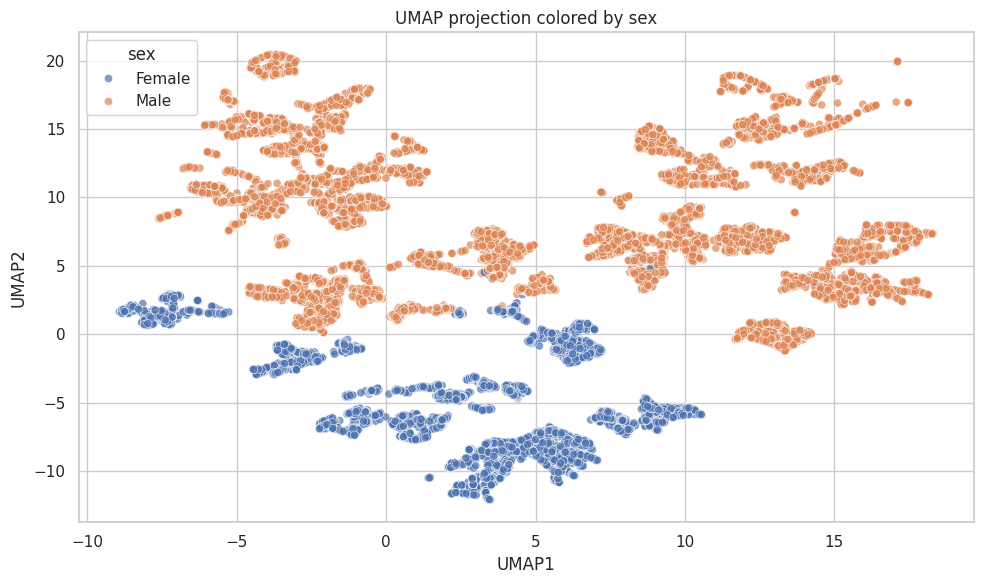

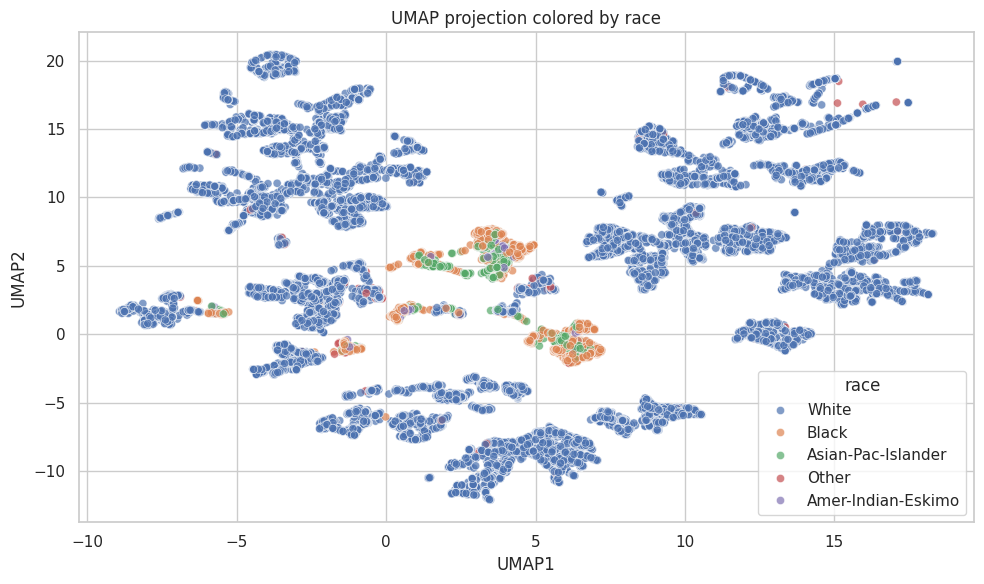

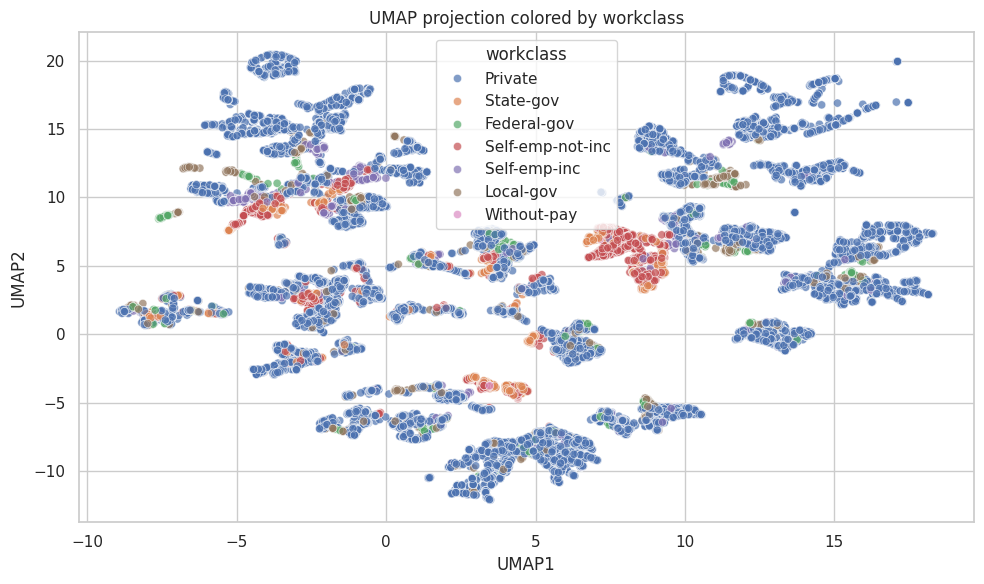

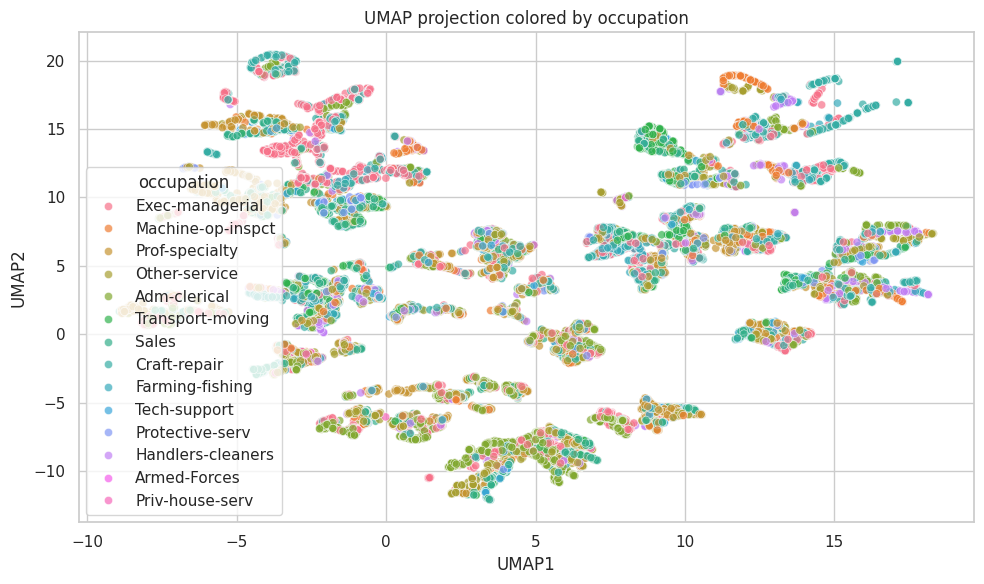

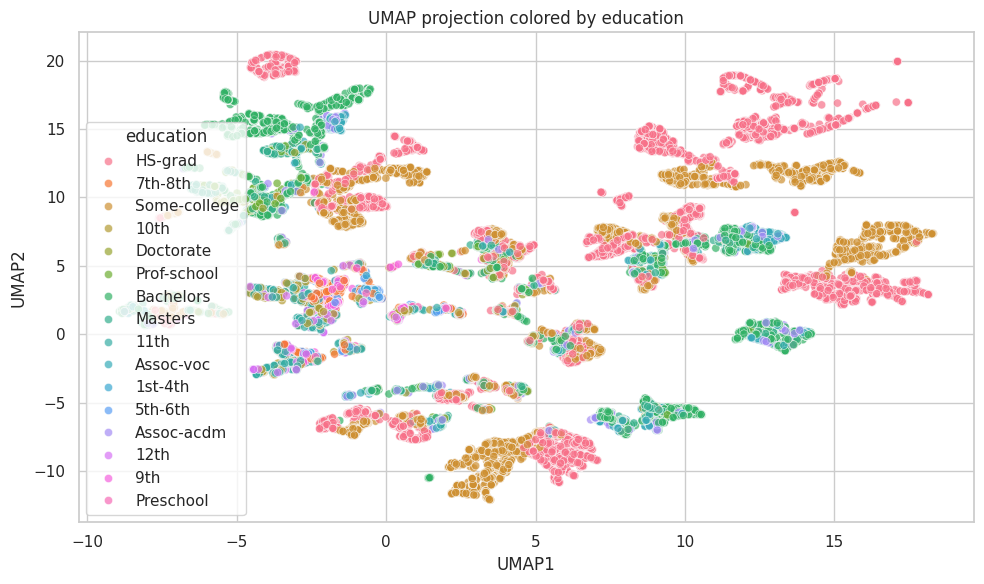

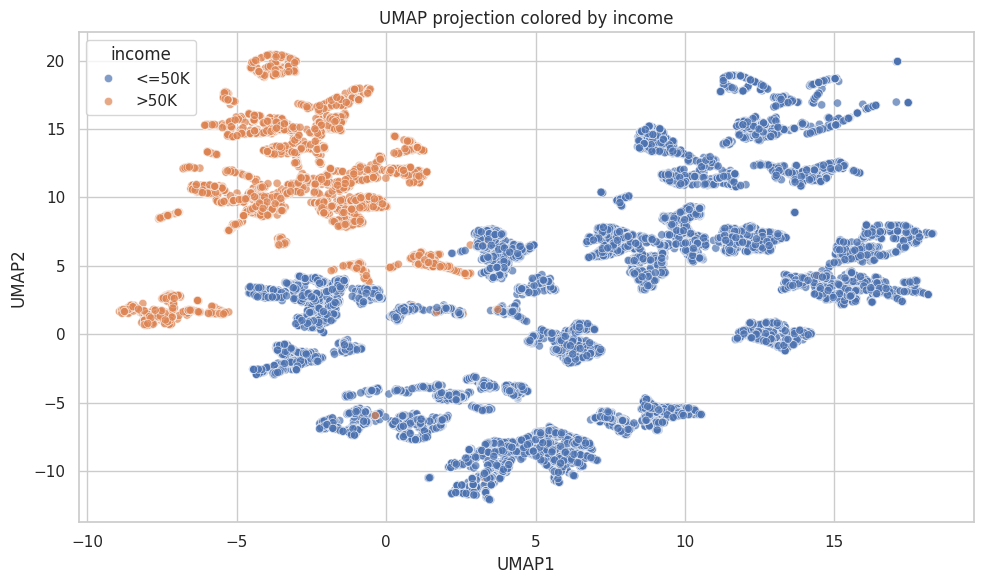

In [ ]:
emb = pd.DataFrame(xt, columns=["UMAP1", "UMAP2"], index=df.index)

# Add categorical columns (like in your t-SNE / PCA plots)
for col in ["sex", "race", "workclass", "occupation", "education", "income"]:
    emb[col] = categorical_col[col].astype(str)

# Plot each categorical label
for col in ["sex", "race", "workclass", "occupation", "education", "income"]:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=emb, x="UMAP1", y="UMAP2", hue=col, s=35, alpha=0.7)
    plt.title(f"UMAP projection colored by {col}")
    plt.legend(title=col, loc="best")
    plt.tight_layout()
    plt.show()


In [ ]:
print(df[numeric_cols])


            age  workclass  education  education.num  marital.status  \
1      3.317157   -0.20898   0.174959      -0.440434        2.283147   
3      1.184832   -0.20898  -1.399020      -2.402221       -1.722039   
4      0.194824   -0.20898   1.224279      -0.048076        1.615616   
5     -0.338257   -0.20898   0.174959      -0.440434       -1.722039   
6     -0.033639   -0.20898  -2.710670      -1.617506        1.615616   
...         ...        ...        ...            ...             ...   
32556 -1.252110   -0.20898   1.224279      -0.048076        0.948085   
32557 -0.871338   -0.20898  -0.874360       0.736639       -0.386977   
32558  0.118670   -0.20898   0.174959      -0.440434       -0.386977   
32559  1.489450   -0.20898   0.174959      -0.440434        2.283147   
32560 -1.252110   -0.20898   0.174959      -0.440434        0.948085   

       occupation  relationship      race       sex  hours.per.week  \
1       -0.734570     -0.261297  0.385108 -1.443574       -1.914

/home/copper/Y/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (30139, 2)


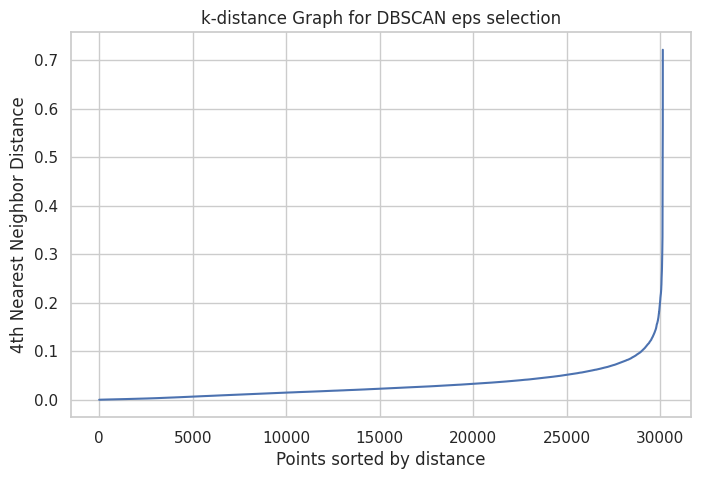


Cluster counts:
 cluster
-1        13
 0      2317
 1        21
 2      1037
 3       862
        ... 
 290       7
 291       7
 292       9
 293       7
 294       6
Name: count, Length: 296, dtype: int64
Silhouette Score (excluding noise): 0.328


/tmp/ipykernel_40823/3290371574.py:96: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


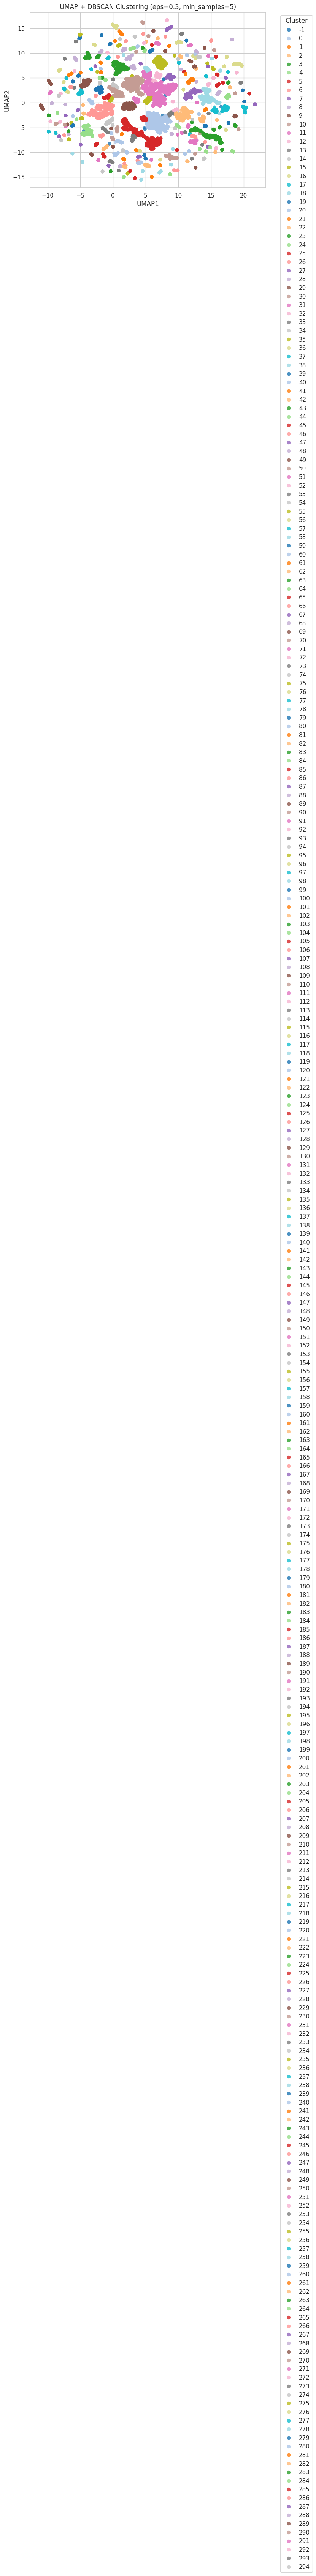

In [ ]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import umap.umap_ as umap

# --- CONFIGURATION ---
RANDOM_STATE = 42

# --- LOAD YOUR DATA ---
# Replace `df` or `X` with your dataset (numerical features only)
# Example: X = df.select_dtypes(include=[np.number])
X = df.select_dtypes(include=[np.number]).copy()

# --- STANDARDIZE ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- DIMENSION REDUCTION ---
# Choose one: PCA or UMAP
use_umap = True  # set to False if you want PCA instead

if use_umap:
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric="euclidean",
        random_state=RANDOM_STATE,
    )
    X_emb = reducer.fit_transform(X_scaled)
    method = "UMAP"
else:
    reducer = PCA(n_components=2, random_state=RANDOM_STATE)
    X_emb = reducer.fit_transform(X_scaled)
    method = "PCA"

print(f"{method} embedding shape:", X_emb.shape)

# --- EPS SELECTION VIA K-DISTANCE PLOT ---
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_emb)
distances, indices = neighbors_fit.kneighbors(X_emb)
distances = np.sort(distances[:, 4])
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title("k-distance Graph for DBSCAN eps selection")
plt.xlabel("Points sorted by distance")
plt.ylabel("4th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

# Manually inspect plot, then set eps around the 'elbow' point
EPS_VALUE = 0.3  # adjust based on elbow observation
MIN_SAMPLES = 5

# --- DBSCAN CLUSTERING ---
db = DBSCAN(eps=EPS_VALUE, min_samples=MIN_SAMPLES, metric="euclidean", n_jobs=-1)
labels = db.fit_predict(X_emb)

# --- CLUSTER STATS ---
df["cluster"] = labels
cluster_counts = df["cluster"].value_counts().sort_index()
print("\nCluster counts:\n", cluster_counts)

# --- SILHOUETTE SCORE ---
mask = labels != -1
if mask.sum() > 1 and len(set(labels[mask])) > 1:
    sil_score = silhouette_score(X_emb[mask], labels[mask])
    print(f"Silhouette Score (excluding noise): {sil_score:.3f}")
else:
    print("Silhouette score not computed — only one cluster or all noise.")

# --- VISUALIZE CLUSTERS ---
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_emb[:, 0],
    y=X_emb[:, 1],
    hue=labels,
    palette="tab20",
    s=40,
    alpha=0.8,
    edgecolor=None,
    legend="full",
)
plt.title(f"{method} + DBSCAN Clustering (eps={EPS_VALUE}, min_samples={MIN_SAMPLES})")
plt.xlabel(f"{method}1")
plt.ylabel(f"{method}2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
